In [1]:
import numpy as np
import pandas as pd

Cargamos y visualizamos los datos

In [2]:
# importamos el Dataset
# Al estar en la misma carpeta, solo necesitamos el nombre
path_local = "data/elnino.csv"

# 1. Definimos la lista con los nombres oficiales en minúsculas
columnas_minuscula = [
    'observation', 'year', 'month', 'day', 'date', 
    'latitude', 'longitude', 'zonal_winds', 'meridional_winds', 
    'humidity', 'air_temp', 'sst'
]

# 2. Leemos el archivo aplicando la nueva lista en minúsculas
df = pd.read_csv(
    path_local, 
    sep=',', 
    names=columnas_minuscula, 
    header=None, 
    skiprows=1
)

# Vamos a ver la forma del dataset para entender cuántas filas y columnas tenemos
dfshape = df.shape
print(f"El dataset tiene {dfshape[0]} filas y {dfshape[1]} columnas.")

# 3. Comprobamos la estructura
df.info()

El dataset tiene 178080 filas y 12 columnas.
<class 'pandas.DataFrame'>
RangeIndex: 178080 entries, 0 to 178079
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   observation       178080 non-null  int64  
 1   year              178080 non-null  int64  
 2   month             178080 non-null  int64  
 3   day               178080 non-null  int64  
 4   date              178080 non-null  int64  
 5   latitude          178080 non-null  float64
 6   longitude         178080 non-null  float64
 7   zonal_winds       178080 non-null  str    
 8   meridional_winds  178080 non-null  str    
 9   humidity          178080 non-null  str    
 10  air_temp          178080 non-null  str    
 11  sst               178080 non-null  str    
dtypes: float64(2), int64(5), str(5)
memory usage: 19.4 MB


In [3]:
# Vamos a ver la forma del dataset para entender cuántas filas y columnas tenemos
dfshape = df.shape
print(f"El dataset tiene {dfshape[0]} filas y {dfshape[1]} columnas.")

El dataset tiene 178080 filas y 12 columnas.


In [4]:
# Finalmente, un conteo de valores nulos por columna nos ayudará a identificar si necesitamos hacer limpieza de datos antes de entrenar nuestros modelos
print(df.isnull().sum())
df.head()

observation         0
year                0
month               0
day                 0
date                0
latitude            0
longitude           0
zonal_winds         0
meridional_winds    0
humidity            0
air_temp            0
sst                 0
dtype: int64


,observation,year,month,day,date,latitude,longitude,zonal_winds,meridional_winds,humidity,air_temp,sst
0,1,80,3,7,800307,-0.02,-109.46,-6.8,0.7,.,26.14,26.24
1,2,80,3,8,800308,-0.02,-109.46,-4.9,1.1,.,25.66,25.97
2,3,80,3,9,800309,-0.02,-109.46,-4.5,2.2,.,25.69,25.28
3,4,80,3,10,800310,-0.02,-109.46,-3.8,1.9,.,25.57,24.31
4,5,80,3,11,800311,-0.02,-109.46,-4.2,1.5,.,25.3,23.19


In [5]:
df.dtypes

observation           int64
year                  int64
month                 int64
day                   int64
date                  int64
latitude            float64
longitude           float64
zonal_winds             str
meridional_winds        str
humidity                str
air_temp                str
sst                     str
dtype: object

# Limpiamos y formateamos los datos

In [6]:
# 1. Eliminar duplicados si los hay
df = df.drop_duplicates()

# 2. Reemplazamos los puntos aislados por valores nulos reales (NaN)
df = df.replace('.', np.nan)

# 3. Creamos una fecha real combinando las columnas de año, mes y día
df['complete_date'] = pd.to_datetime(
    (df['year'] + 1900).astype(str) + '-' + 
    df['month'].astype(str) + '-' + 
    df['day'].astype(str)
)

# 4. Reemplazamos la antigua columna 'date' por esta nueva con el formato correcto
df['date'] = df['complete_date'].dt.strftime('%Y-%m-%d')

# 5. Forzamos a que las columnas físicas sean numéricas
columnas_numericas = ['latitude', 'longitude', 'zonal_winds', 'meridional_winds', 'sst']
for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [7]:
df.dtypes

observation                  int64
year                         int64
month                        int64
day                          int64
date                           str
latitude                   float64
longitude                  float64
zonal_winds                float64
meridional_winds           float64
humidity                       str
air_temp                       str
sst                        float64
complete_date       datetime64[us]
dtype: object

Hipótesis de trabajo:
El aumento de la temperatura superficial del mar (SST) junto con variaciones extremas de los vientos asociados a eventos de El Niño aleja a ciertas especies marinas comerciales de sus zonas habituales de captura.

Objetivo:
Crear un Dashboard de datos históricos sobre variaciones del viento y la temperatura del Pacífico para ayudar a empresas vulnerables al clima (como pesqueras y aseguradoras marítimas) a anticipar pérdidas y gestionar sus riesgos operativos.

In [8]:
# Lista de columnas a eliminar 
columnas_a_eliminar = ['date', 'day', 'year', 'month', 'humidity', 'air_temp']

df = df.drop(columns=columnas_a_eliminar, errors='ignore')

In [10]:
#  Guardar el archivo definitivo para los modelos
df.to_csv('dataset_elnino_final.csv', index=False)

print("✅ Archivo 'dataset_elnino_final.csv' creado con éxito.")
print(f"📊 Shape final: {df.shape}")
print(f"📋 Columnas resultantes: {list(df.columns)}")

✅ Archivo 'dataset_elnino_final.csv' creado con éxito.
📊 Shape final: (178080, 7)
📋 Columnas resultantes: ['observation', 'latitude', 'longitude', 'zonal_winds', 'meridional_winds', 'sst', 'complete_date']


In [9]:
# visualización de la tabla que hemos creado con SQL (notebook: sql_to_python) para el análisis exploratorio de datos (EDA)
# Volver a cargar el archivo para actualizar los datos en la memoria de este notebook
df = pd.read_csv('data/table_atmospheric_oceanic_dataset.csv')

# Comprobar que aparecen las nuevas variables temporales
df.head()

,complete_date,latitude,longitude,zonal_winds,meridional_winds,sst_today,sst_avg_fortnight,wind_max_fortnight,avg_zonal_wind_15d
0,1980-03-07,-0.02,-109.46,-6.8,0.7,26.24,26.240,-6.8,-6.80
1,1980-03-08,-0.02,-109.46,-4.9,1.1,25.97,26.105,-4.9,-5.85
2,1980-03-09,-0.02,-109.46,-4.5,2.2,25.28,25.830,-4.5,-5.40
3,1980-03-10,-0.02,-109.46,-3.8,1.9,24.31,25.450,-3.8,-5.00
4,1980-03-11,-0.02,-109.46,-4.2,1.5,23.19,24.998,-3.8,-4.84


In [10]:
df.shape

(178080, 9)

Variables seleccionadas para EDA:

Selcionamos variables relacionadas con la temperatura del mar y el viento, ya que son los principales indicadores de eventos de El Niño y tienen un impacto directo en la distribución de las especies marinas, algo que interesa a las empresas pesqueras y aseguradoras.  

Al demostrar que estas se correlan entre sí y analizando también como lo hacen, además de su comportamiento histórico, podemos ayudar a las compañías a anticipar estos eventos. 

También podría ser el primer paso para construir un modelo predictivo que permitiría anticipar eventos extremos, lo que es crucial para la toma de decisiones en estas industrias.

- sst_today (temperatura superficial del mar del día actual) por coordenada
- sst_avg_fortnight (promedio de temperatura de los últimos 14 días) por coordenada
- wind_max_fortnight (viento máximo de los últimos 14 días) por coordenada
- avg_zonal_wind_15d (viento promedio de los últimos 14 días) por coordenada



Realizamos un informe estadístico descriptivo de las variables clave para entender su distribución, tendencia central y dispersión, lo que nos ayudará a identificar patrones o anomalías en los datos relacionados con el viento y la temperatura del Pacífico, fundamentales para nuestro análisis de eventos de El Niño.

In [11]:
# Resumen estadístico descriptivo de las variables clave 
# Carga del dataset desde la carpeta data
df_oceanico = pd.read_csv('data/table_atmospheric_oceanic_dataset.csv')


# Definimos la función aceptando el dataframe como argumento genérico 'df'
def generar_estadistica_descriptiva(df: pd.DataFrame) -> None:
    
    print("=== ESTADÍSTICA DESCRIPTIVA DE LAS VARIABLES CLAVE ===")

    variables_clave = [
        'sst_today',
        'sst_avg_fortnight',
        'zonal_winds',
        'wind_max_fortnight',
        'meridional_winds',
    ]

    # Usamos el argumento 'df' que entra a la función
    resumen_estadistico = df[variables_clave].describe().round(2)

    print(resumen_estadistico)
    print("\n" + "=" * 60 + "\n")


# Llamamos a la función pasándole nuestra variable cargada
generar_estadistica_descriptiva(df_oceanico)


=== ESTADÍSTICA DESCRIPTIVA DE LAS VARIABLES CLAVE ===
       sst_today  sst_avg_fortnight  zonal_winds  wind_max_fortnight  \
count  161073.00          162861.00    152917.00           155601.00   
mean       27.72              27.71        -3.30               -1.64   
std         2.06               2.04         3.37                3.76   
min        17.35              17.68       -12.40              -11.10   
25%        26.77              26.76        -5.80               -4.50   
50%        28.29              28.29        -4.00               -2.30   
75%        29.23              29.23        -1.40                0.80   
max        31.26              31.25        14.30               14.30   

       meridional_winds  
count         152918.00  
mean               0.25  
std                3.00  
min              -11.60  
25%               -1.70  
50%                0.30  
75%                2.30  
max               13.00  




Temperatura media del agua bastante alta en los últimos 14 días (mean: sst_avg_fortnight = 27.71) y también de manera general (mean: sst_today = 27.72), lo que podría indicar un evento de El Niño, algo que también las temperaturas máximas alcanzadas (31.26, 31.25). Sin embargo, es importante considerar otros factores como el viento para confirmar esta hipótesis. 
Si tenemos en cuenta el hecho de que la media de zonal_winds sea negativa (-3.30), un brusco cambio hacia valores positivos (max: zonal_winds = 14.30) podría indicar un cambio en los patrones de viento asociados a El Niño.

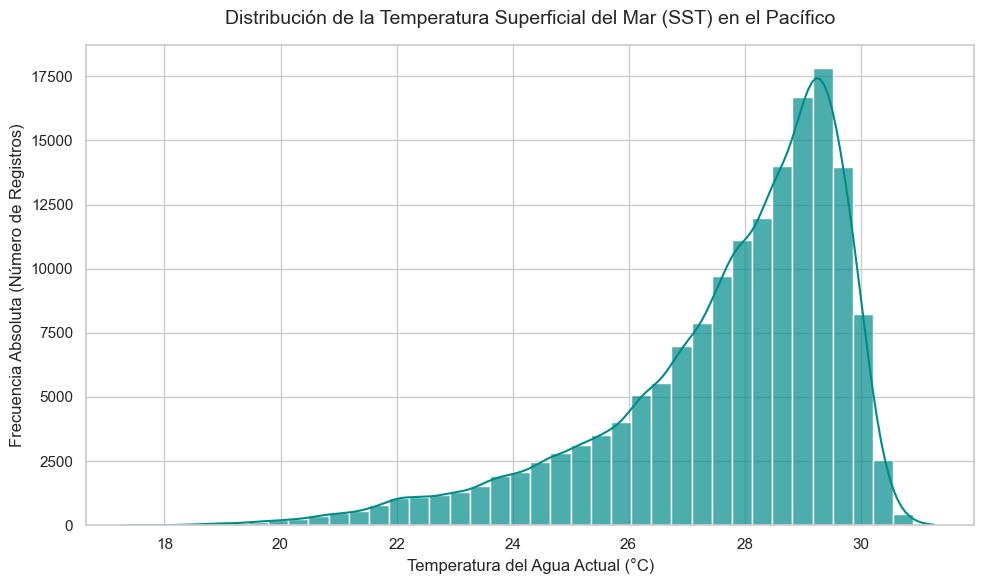

In [12]:
# Visualización de la distribución de la temperatura superficial del mar (SST) con un histograma y curva de densidad (KDE)

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset puro
df_oceanico = pd.read_csv("data/table_atmospheric_oceanic_dataset.csv")

# 2. Configurar el estilo visual moderno
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Dibujar el histograma con curva de densidad (KDE)
sns.histplot(
    data=df_oceanico,
    x="sst_today",
    kde=True,
    color="darkcyan",
    bins=40,
    alpha=0.7,
)

# 4. Añadir etiquetas académicas claras en español
plt.title(
    "Distribución de la Temperatura Superficial del Mar (SST) en el Pacífico",
    fontsize=14,
    pad=15,
)
plt.xlabel("Temperatura del Agua Actual (°C)", fontsize=12)
plt.ylabel("Frecuencia Absoluta (Número de Registros)", fontsize=12)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

"El histograma muestra una clara asimetría negativa en la Temperatura Superficial del Mar (SST). El núcleo de las observaciones se concentra en un rango cálido de entre 28°C y 29.5°C, reflejando las condiciones tropicales habituales de la región. Se observa un pico significativo por encima de los 30°C que puede ser asociado con los eventos más agudos de El Niño." La prolongada cola hacia la izquierda (valores inferiores a 24°C) podería indicar episodios de La Niña, caracterizados por temperaturas más frías en la superficie del mar. 

Calculamos la correlación entre variables de temperatura y viento para evaluar la relación entre estas variables, lo que es crucial para entender cómo las variaciones en el viento pueden influir en la temperatura del océano y, por ende, en los eventos de El Niño.

In [13]:
# coeficiente de correlación entre la temperatura superficial del mar de hoy (sst_today) y el promedio de viento zonal de los últimos 15 días (avg_zonal_wind_15d)
correlation: float = df_oceanico['sst_today'].corr(df_oceanico['avg_zonal_wind_15d'])

print(f"Coeficiente de correlación entre sst_today y avg_zonal_wind_15d: {correlation:.4f}")


Coeficiente de correlación entre sst_today y avg_zonal_wind_15d: 0.3933


In [14]:
# coeficiente de correlación entre la temperatura superficial del mar de hoy (sst_today) y el viento máximo de los últimos 14 días (wind_max_fortnight)
correlation: float = df_oceanico['sst_today'].corr(df_oceanico['wind_max_fortnight'])

print(f"Coeficiente de correlación entre sst_today y wind_max_fortnight: {correlation:.4f}")


Coeficiente de correlación entre sst_today y wind_max_fortnight: 0.4325


In [15]:
# coeficiente de correlación
correlation: float = df_oceanico['sst_avg_fortnight'].corr(df_oceanico['avg_zonal_wind_15d'])

print(f"Coeficiente de correlación entre sst_avg_fortnight y avg_zonal_wind_15d: {correlation:.4f}")


Coeficiente de correlación entre sst_avg_fortnight y avg_zonal_wind_15d: 0.3925


In [16]:
# coeficiente de correlación
correlation: float = df_oceanico['sst_avg_fortnight'].corr(df_oceanico['wind_max_fortnight'])

print(f"Coeficiente de correlación entre sst_avg_fortnight y wind_max_fortnight: {correlation:.4f}")


Coeficiente de correlación entre sst_avg_fortnight y wind_max_fortnight: 0.4325


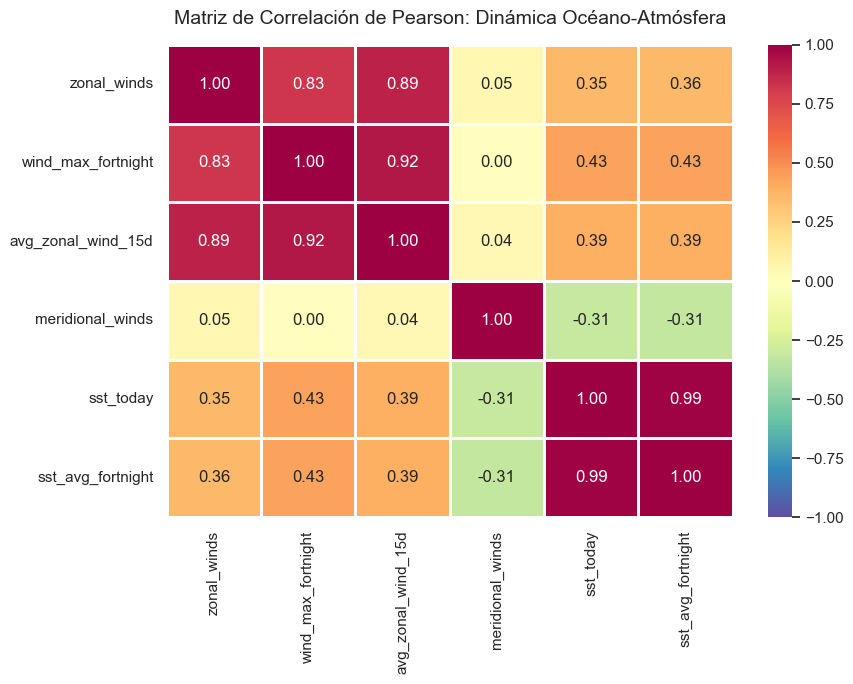

In [17]:
#1. Seleccionar únicamente las columnas físicas reales

columnas_fisicas = [
    'zonal_winds',
    'wind_max_fortnight',
    'avg_zonal_wind_15d',
    'meridional_winds',
    'sst_today',
    'sst_avg_fortnight',
]

# 2. Calcular la matriz de Pearson
matriz_corr = df_oceanico[columnas_fisicas].corr(method="pearson")

# 3. Configurar el lienzo del gráfico
plt.figure(figsize=(9, 7))

# 4. Dibujar el mapa de calor usando una paleta térmica (Spectral_r)
sns.heatmap(
    matriz_corr,
    annot=True,  # Pinta los números dentro de los cuadrados
    cmap="Spectral_r",  # Rojo para correlación positiva, Azul para negativa
    fmt=".2f",  # Muestra 2 decimales
    linewidths=0.8,
    vmin=-1,
    vmax=1,  # Forzamos los límites matemáticos de Pearson
)

plt.title(
    "Matriz de Correlación de Pearson: Dinámica Océano-Atmósfera",
    fontsize=14,
    pad=15,
)
plt.tight_layout()
plt.show()

Nuestra matriz de correlación demuestra la conexión entre el viento y la temperatura del Pacífico. El indicador atmosférico wind_max_fortnight presenta la mayor correlación con la temperatura del mar (0.43), confirmando que las variaciones del viento actúan como señales tempranas de alerta. Además, la persistencia térmica del océano (0.99) garantiza que, una vez detectado el riesgo en nuestro Dashboard, las empresas pesqueras disponen de una ventana de tiempo operativa fiable para tomar decisiones estratégicas antes de sufrir pérdidas."

Hacemos un mapa de dispersión para visualizar la relación entre la temperatura del mar (sst_today) y el viento máximo (wind_max_fortnight), lo que nos permitirá identificar patrones o tendencias en los datos que podrían estar relacionados con eventos de El Niño.

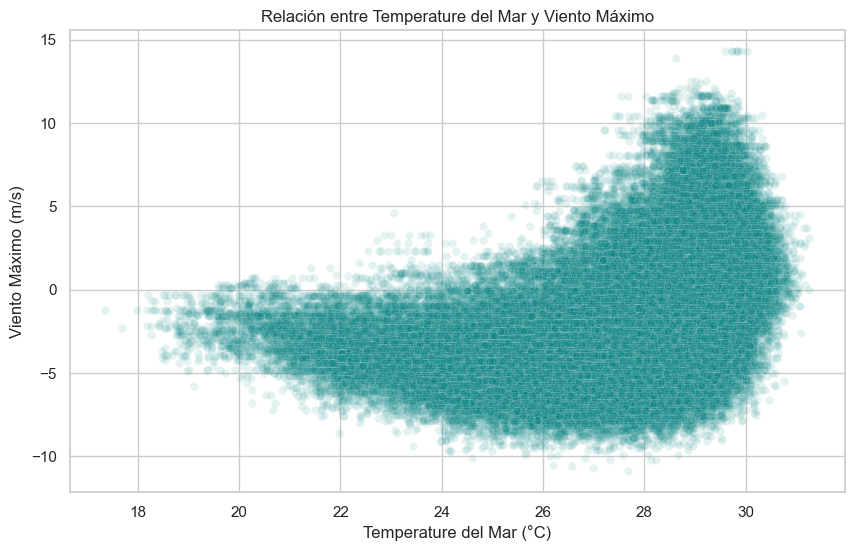

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_oceanico, x='sst_today', y='wind_max_fortnight', alpha=0.1, color='teal')
plt.title('Relación entre Temperature del Mar y Viento Máximo')
plt.xlabel('Temperature del Mar (°C)')
plt.ylabel('Viento Máximo (m/s)')
plt.show()

Este gráfico de dispersión confirma las tendencias que hemos observado hasta ahora. Constatmos que las temperaturas críticas superiores a a la media de 27.72°C (zona derecha) solo ocurren cuando los vientos rompen su patrón habitual y registran valores positivos o cercanos a cero. Esto demuestra visualmente que monitorizar las anomalías del viento en nuestro panel permite anticipar de manera razonable cuándo el mar entrará en la zona de riesgo térmico, dando tiempo a las pesqueras para proteger sus operaciones.

# KPIs (Indicadores Clave de Rendimiento) Operativos y de Riesgo para companías pesqueras y aseguradoras marítimas

- Calculamos KPIs de riesgo que integraremos a nuestro Dashboard para que las empresas puedan anticipar pérdidas y gestionar sus riesgos operativos relacionados con eventos de El Niño. Estos KPIs se basarán en umbrales críticos de temperatura del mar y viento, así como en la frecuencia de eventos extremos registrados en el pasado:

1. KPI de Riesgo por Temperatura del Mar (kpi_temp_risk): Proporción de días en los últimos 15 días donde la temperatura del mar (sst_avg_fortnight) superó un umbral crítico (por ejemplo, 28°C). Este KPI indicará el nivel de riesgo térmico para las operaciones pesqueras.

2. KPI de Riesgo de Viento (kpi_wind_risk): mide la inestabilidad de la atmósfera basada en la Desviación típica del viento zonal

3. KPI de Frecuencia de Eventos Extremos (kpi_extreme_events): Número de eventos extremos registrados en los últimos 14 días, definidos como días donde tanto la temperatura del mar superó el umbral crítico como el viento máximo superó su umbral crítico. Este KPI proporcionará una medida integrada del riesgo combinado de temperatura y viento.

4. También podríamos considerar la creación de un KPI de Alerta Temprana (kpi_early_warning) que combine los indicadores de temperatura y viento para proporcionar una señal de alerta temprana cuando se detecten condiciones que históricamente han precedido a eventos de El Niño, permitiendo a las empresas tomar medidas preventivas con mayor anticipación.

Estos KPIs permitirán a las empresas pesqueras y aseguradoras marítimas monitorear de manera proactiva las condiciones del océano y tomar decisiones informadas para mitigar los riesgos asociados con eventos de El Niño.

Por otra parte, calcularemos KPIs tecnícos 

In [19]:
# KPI1 de Riesgo por Temperatura del Mar (kpi_temp_risk)
# Definir la constante de negocio (la media que descubrimos en nuestro análisis)
media_historica_sst = 27.72
umbral_alerta_riesgo = 28

# KPI 1: Índice  KPI de Riesgo por Temperatura del Mar (kpi_temp_risk) para cada registro
df_oceanico['kpi_temp_risk'] = df_oceanico['sst_avg_fortnight'] > umbral_alerta_riesgo

In [20]:
# KPI2:  KPI de Riesgo de Viento (kpi_wind_risk)

inestabilidad_viento = df_oceanico["zonal_winds"].std()

In [21]:
#KPI3: KPI de Frecuencia de Eventos Extremos (kpi_extreme_events)

# Definición de las condiciones de riesgo combinadas para el negocio
condicion_temperatura = df_oceanico["sst_avg_fortnight"] > umbral_alerta_riesgo
condicion_viento_positivo = (
    df_oceanico["zonal_winds"] > 0
)  # El viento cambia de rumbo hacia el Este

# KPI 3: Frecuencia de Eventos Extremos (Cruce de Temperatura y Viento)
df_eventos_extremos = df_oceanico[
    condicion_temperatura & condicion_viento_positivo
]
kpi_extreme_events = df_eventos_extremos.shape[0]

# KPI 3b: Proporción de impacto (Qué porcentaje del histórico total representan estos eventos)
porcentaje_eventos_extremos = (kpi_extreme_events / len(df_oceanico)) * 100

In [23]:
# KPI4:  KPI de Alerta Temprana (kpi_early_warning)

# Definición de la condición de alerta temprana 
condicion_alerta_temprana = (
    (df_oceanico['sst_today'] > umbral_alerta_riesgo) &
    (df_oceanico['zonal_winds'] > 0)
)
kpi_early_warning = df_oceanico[condicion_alerta_temprana].shape[0]

# Mostrar los resultados ejecutivos
print('=== KPIs DE RIESGO PARA EL DASHBOARD ===')
print(
    f'. Umbral de Alerta Definido: > {umbral_alerta_riesgo}°C (Media: {media_historica_sst}°C)'
)
print(
    f'1. KPI de Riesgo por Temperatura del Mar: {df_oceanico["kpi_temp_risk"].mean():.2f}°C por encima del umbral de riesgo'
)
print(
    f'2. KPI de Riesgo de Viento: {inestabilidad_viento:.2f} m/s'
)
print(
    f'3. KPI de Frecuencia de Eventos Extremos: {kpi_extreme_events} registros'
)
print(
    f'3.b. Impacto en el histórico global: {porcentaje_eventos_extremos:.2f}% de los datos'
)
print(
    f'4. KPI de Alerta Temprana: {kpi_early_warning} registros'
)

=== KPIs DE RIESGO PARA EL DASHBOARD ===
. Umbral de Alerta Definido: > 28°C (Media: 27.72°C)
1. KPI de Riesgo por Temperatura del Mar: 0.51°C por encima del umbral de riesgo
2. KPI de Riesgo de Viento: 3.37 m/s
3. KPI de Frecuencia de Eventos Extremos: 19491 registros
3.b. Impacto en el histórico global: 10.95% de los datos
4. KPI de Alerta Temprana: 19315 registros


Podemos, claramente establecer una relación jerárquica de riesgo, a partir de nuetros KPIs 3 y 4. El KPI 4 (Alerta Temprana) actúa como un indicador adelantado que detecta anomalías concurrentes en el viento y la temperatura en el día actual (sst_today). Por otro lado, el KPI 3 (Eventos Extremos) representa la consolidación de dicho riesgo en el medio plazo: media de 15 días (sst_avg_fortnight). Estadísticamente, un incremento sostenido en la frecuencia del KPI 4 precede y activa el KPI 3, algo que las empresas pesqueras y aseguradoras deben tener en cuenta para prever crisis operativas con días de antelación. 

"Nuestro análisis identifica un Índice de Riesgo de Viento de 3.37 m/s. Este índice nos permite medir cuánto se suelen alejar nuestros datos reales de la media. el resultado obtenido representa la volatilidad estructural de la atmósfera en el Pacífico que ya hemos observado en nuestra gráfica de dispersión. Se trata de un indicador fundamental, para una compañía de seguros marítimos, demuestra que el comportamiento del viento no es lineal ni pasivo, sino que cuenta con una alta variabilidad capaz de romper el equilibrio térmico del océano, ya que como lo hemos visto en nuestro análisis existente una correlación bastante fuerte entre temperatura y viento. Al integrar esta volatilidad en nuestro Dashboard, podemos detectar los desvíos críticos del viento antes de que consoliden un impacto térmico en la superficie del mar. 

El análisis descriptivo revela además que el KPI 3 (Frecuencia de Eventos Extremos) registra un total de 19,491 eventos, lo que representa el 10.95% del histórico global. Desde la perspectiva de la gestión del riesgo analítico, este porcentaje confirma que las crisis concurrentes de acoplamiento océano-atmósfera (mar cálido y vientos del oeste recurrentes) constituyen una anomalía estructural con impacto bastante alto. Una probabilidad de ocurrencia cercana al 11% justifica la necesidad comercial de implementar sistemas de monitorización y alertas predictivas, ya que estas ventanas críticas comprometen la estabilidad financiera de la flota pesquera 1 de cada 10 días.

Hacemos visualizaciones de los KPIs para ver mejor nuestros resultados y comunicar de manera efectiva el riesgo a las partes interesadas, como las empresas pesqueras y aseguradoras marítimas, para que puedan tomar decisiones informadas basadas en los datos históricos de eventos de El Niño.

# Visualización de KPIs para comunicar el riesgo a las partes interesadas

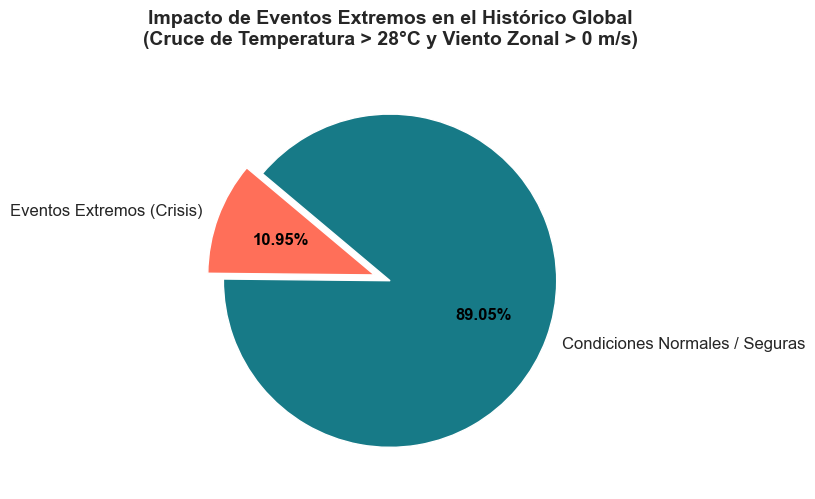

In [ ]:
# Pie chart para visualizar el impacto de los eventos extremos en el histórico global

# 1. Definir los datos basados en tus resultados de la terminal
porcentaje_extremo = 10.95
porcentaje_normal = 100.00 - porcentaje_extremo

datos = [porcentaje_extremo, porcentaje_normal]
etiquetas = ["Eventos Extremos (Crisis)", "Condiciones Normales / Seguras"]

# Colores estratégicos de negocio (Coral para el riesgo, gris claro para la normalidad)
colores = ["#FF6F59", "#177A87"]

# "Explode" sirve para separar un poco la porción de crisis y llamar la atención del cliente
desfase = (0.1, 0)

# 2. Construir la figura
plt.figure(figsize=(8, 8))
parches, textos, autotextos = plt.pie(
    datos,
    explode=desfase,
    labels=etiquetas,
    colors=colores,
    autopct="%1.2f%%",
    startangle=140,
    textprops={"fontsize": 12},
)

# Estilizar los porcentajes dentro del gráfico para que se vean profesionales
for autotexto in autotextos:
    autotexto.set_color("black")
    autotexto.set_weight("bold")

# 3. Título ejecutivo del gráfico
plt.title(
    "Impacto de Eventos Extremos en el Histórico Global\n(Cruce de Temperatura > 28°C y Viento Zonal > 0 m/s)",
    fontsize=14,
    pad=20,
    weight="bold",
)

plt.tight_layout()
plt.show()

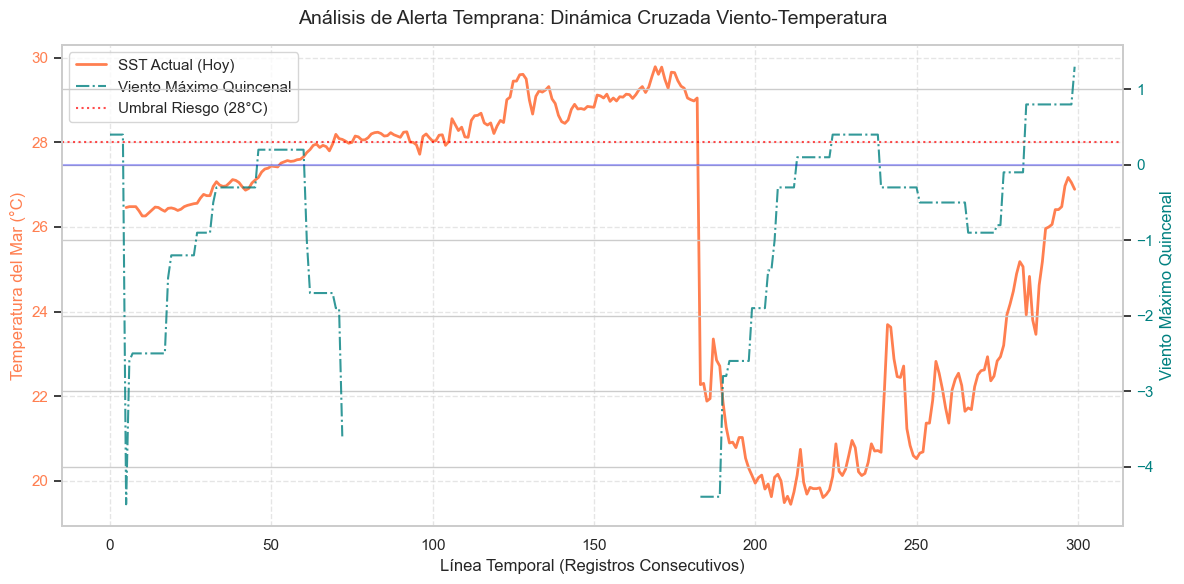

In [47]:
# Gráfico combinado de líneas para mostrar la dinámica cruzada entre temperatura y viento
# Para este ejemplo visual, tomamos un fragmento continuo de registros (ej. 300 días)
# para que las curvas se aprecien con total nitidez.
df_fragmento = df_oceanico.iloc[600:900].reset_index(drop=True)

# 2. Inicializar la figura y el primer eje (Eje Y Izquierdo - Temperatura)
fig, ax1 = plt.subplots(figsize=(12, 6))

color_temp = "coral"
ax1.set_xlabel("Línea Temporal (Registros Consecutivos)")
ax1.set_ylabel("Temperatura del Mar (°C)", color=color_temp)
linea1 = ax1.plot(
    df_fragmento["sst_today"],
    color=color_temp,
    linewidth=2,
    label="SST Actual (Hoy)",
)
ax1.tick_params(axis="y", labelcolor=color_temp)
ax1.grid(True, linestyle="--", alpha=0.5)

# Límite horizontal del umbral de negocio en el primer eje
ax1.axhline(
    umbral_alerta_riesgo,
    color="red",
    linestyle=":",
    alpha=0.7,
    label=f"Umbral Riesgo ({umbral_alerta_riesgo}°C)",
)

# 3. Crear el segundo eje que comparte el mismo eje X (Eje Y Derecho - Viento Máximo Quincenal)
ax2 = ax1.twinx()

color_viento = "teal"
ax2.set_ylabel("Viento Máximo Quincenal", color=color_viento)
linea2 = ax2.plot(
    df_fragmento["wind_max_fortnight"],
    color=color_viento,
    linewidth=1.5,
    linestyle="-.",
    alpha=0.8,
    label="Viento Máximo Quincenal",
)
ax2.tick_params(axis="y", labelcolor=color_viento)

# Línea de referencia cero para el viento
ax2.axhline(0, color="blue", linestyle="-", alpha=0.3)

# 4. Unificar las leyendas de ambos ejes en un solo cuadro
lineas = linea1 + linea2 + [ax1.get_lines()[-1]]
etiquetas = [l.get_label() for l in lineas]
ax1.legend(lineas, etiquetas, loc="upper left")

plt.title(
    "Análisis de Alerta Temprana: Dinámica Cruzada Viento-Temperatura",
    fontsize=14,
    pad=15,
)
fig.tight_layout()
plt.show()

Esta línea temporal cruzada demuestra la relación de causa y efecto de nuestro modelo. Como se observa a partir del registro 180, una intensificación drástica de los vientos hacia valores negativos provoca un colapso térmico inmediato en el océano. Más importante aún para nuestro análisis: en la fase final (registros 250 a 300), se observa claramente cómo el viento cambia de rumbo hacia valores positivos antes de que la temperatura se dispare. Esto valida nuestro KPI de Alerta Temprana, demostrando que el comportamiento de la atmósfera nos avisa con antelación de los procesos de calentamiento en el mar."

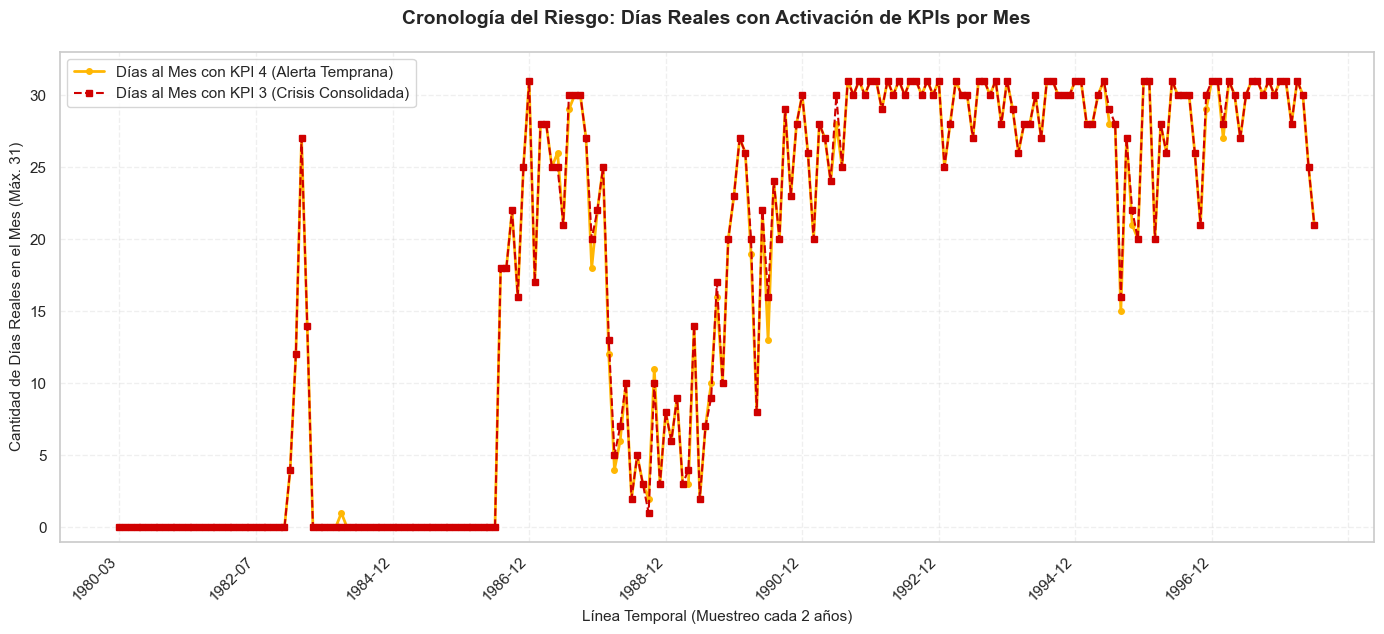

In [38]:



import matplotlib.ticker as ticker

# 1. FORZAR LA LECTURA DE LA FECHA: Convertimos la columna a datetime nativo de Pandas
df_oceanico['complete_date_parsed'] = pd.to_datetime(df_oceanico['complete_date'])

# 2. Definir los activadores diarios (0 o 1) por registro
df_oceanico['kpi_4_act'] = (
    (df_oceanico['sst_today'] > umbral_alerta_riesgo)
    & (df_oceanico['zonal_winds'] > 0)
).astype(int)
df_oceanico['kpi_3_act'] = (
    (df_oceanico['sst_avg_fortnight'] > umbral_alerta_riesgo)
    & (df_oceanico['zonal_winds'] > 0)
).astype(int)

# 3. Colapsar por fecha parseada única para eliminar las múltiples estaciones
df_diario_unico = (
    df_oceanico.groupby('complete_date_parsed')[['kpi_4_act', 'kpi_3_act']]
    .max()
    .reset_index()
)

# 4. Extraer el periodo mensual sobre la columna de fecha ya reconocida
df_diario_unico['año_mes'] = df_diario_unico['complete_date_parsed'].dt.to_period('M')

# 5. Agrupar por mes sumando los días únicos (Resultado real: entre 0 y 31 días)
df_mensual = (
    df_diario_unico.groupby('año_mes')[['kpi_4_act', 'kpi_3_act']]
    .sum()
    .reset_index()
)
df_mensual['año_mes_str'] = df_mensual['año_mes'].astype(str)

# 6. Generar la gráfica corregida y limpia
plt.figure(figsize=(14, 6.5))

plt.plot(
    df_mensual['año_mes_str'],
    df_mensual['kpi_4_act'],
    color='#FFB703',
    marker='o',
    markersize=4,
    linewidth=2,
    label='Días al Mes con KPI 4 (Alerta Temprana)',
)
plt.plot(
    df_mensual['año_mes_str'],
    df_mensual['kpi_3_act'],
    color='#D00000',
    marker='s',
    markersize=4,
    linewidth=1.5,
    linestyle='--',
    label='Días al Mes con KPI 3 (Crisis Consolidada)',
)

# Configurar el muestreo del eje X cada 2 años (24 meses)
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(24))

plt.title(
    'Cronología del Riesgo: Días Reales con Activación de KPIs por Mes',
    fontsize=14,
    pad=20,
    weight='bold',
)
plt.xlabel('Línea Temporal (Muestreo cada 2 años)', fontsize=11)
plt.ylabel('Cantidad de Días Reales en el Mes (Máx. 31)', fontsize=11)

# Límite del eje Y estricto para el calendario
plt.ylim(-1, 33)

plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

Las líneas temporales cruzadas se supereponen perfectamente. Demonstrando que si hay alerta, habrá crisis, y confirmando la relación de causa y efecto entre ambos indicadores. Esto es fundamental para nuestro negocio, ya que valida la utilidad de nuestro KPI de Alerta Temprana, demostrando que el aumento de la temperatura y un cambio significativo en la dirección de los vientos en el océano avisa con antelación de los procesos de calentamiento en el mar, lo que permite a las empresas pesqueras y aseguradoras marítimas tomar medidas preventivas con mayor anticipación. 

Además constamos que el aumento de la recurencia de un numero elevado de días de alerta activa es mayor a partir de la  , lo que refuerza la importancia de monitorear el KPI de Alerta Temprana para anticipar y gestionar eficazmente los riesgos asociados con eventos de El Niño.